In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:

file_nama = 'nama.jpeg' 
file_backlight = 'diri.jpeg'


img_nama_bgr = cv2.imread(file_nama)
img_backlight_bgr = cv2.imread(file_backlight)


img_nama = cv2.cvtColor(img_nama_bgr, cv2.COLOR_BGR2RGB)
img_backlight = cv2.cvtColor(img_backlight_bgr, cv2.COLOR_BGR2RGB)

print("Gambar berhasil diload!")

Gambar berhasil diload!


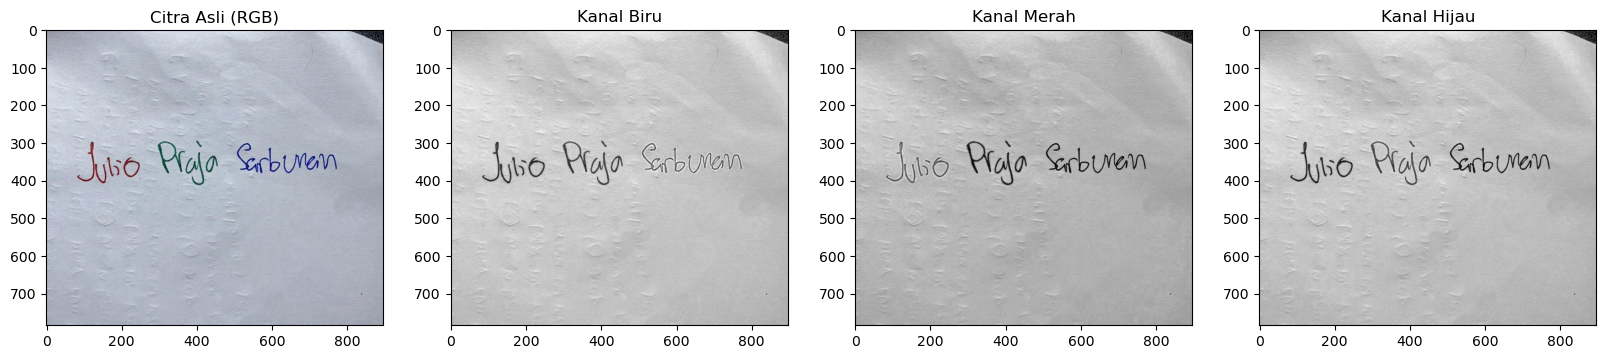

In [9]:

R, G, B = cv2.split(img_nama)


fig, ax = plt.subplots(1, 4, figsize=(20, 5))


ax[0].imshow(img_nama)
ax[0].set_title('Citra Asli (RGB)')


ax[1].imshow(B, cmap='gray'); ax[1].set_title('Kanal Biru')
ax[2].imshow(R, cmap='gray'); ax[2].set_title('Kanal Merah')
ax[3].imshow(G, cmap='gray'); ax[3].set_title('Kanal Hijau')

plt.show()

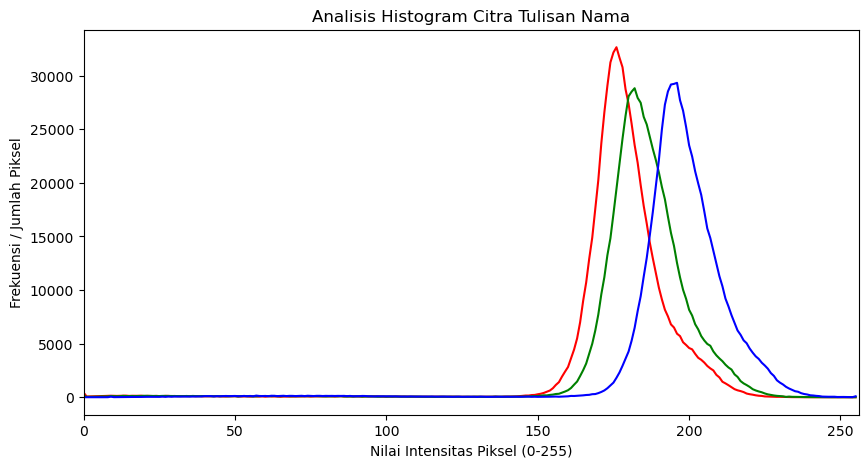

In [10]:

plt.figure(figsize=(10, 5))


colors = ('r', 'g', 'b')


for i, col in enumerate(colors):
    
    hist = cv2.calcHist([img_nama], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    
plt.title('Analisis Histogram Citra Tulisan Nama')
plt.xlabel('Nilai Intensitas Piksel (0-255)')
plt.ylabel('Frekuensi / Jumlah Piksel')
plt.xlim([0, 256]) 
plt.show()

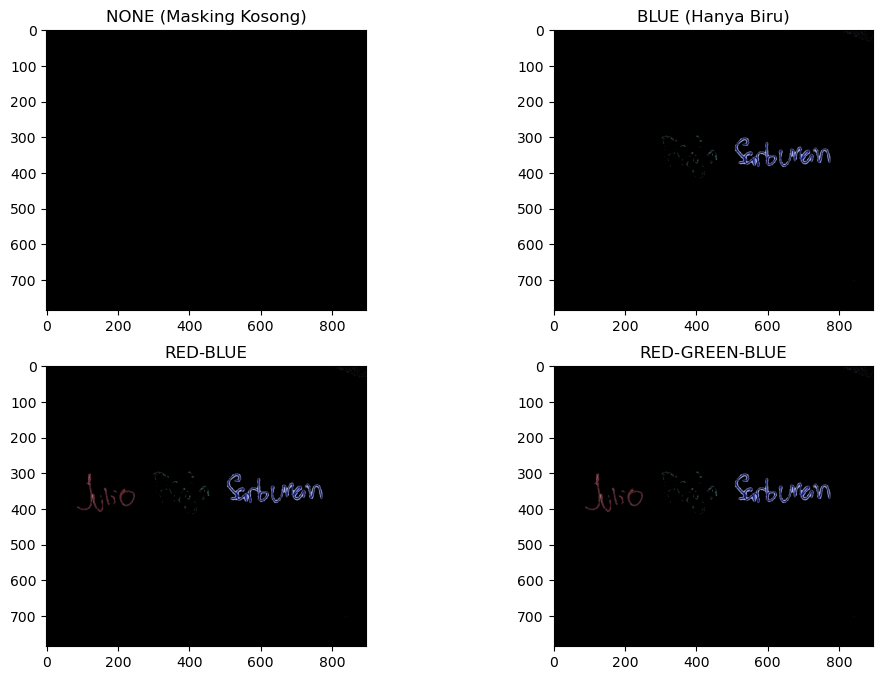

In [11]:

hsv = cv2.cvtColor(img_nama, cv2.COLOR_RGB2HSV)


lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])


lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])


lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([180, 255, 255])


mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
mask_green = cv2.inRange(hsv, lower_green, upper_green)
mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask_red = mask_red1 + mask_red2 


res_blue = cv2.bitwise_and(img_nama, img_nama, mask=mask_blue)
res_green = cv2.bitwise_and(img_nama, img_nama, mask=mask_green)
res_red = cv2.bitwise_and(img_nama, img_nama, mask=mask_red)


img_none = np.zeros_like(img_nama)
img_red_blue = cv2.bitwise_or(res_red, res_blue) 
img_all = cv2.bitwise_or(img_red_blue, res_green) 


fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].imshow(img_none); ax[0,0].set_title('NONE (Masking Kosong)')
ax[0,1].imshow(res_blue); ax[0,1].set_title('BLUE (Hanya Biru)')
ax[1,0].imshow(img_red_blue); ax[1,0].set_title('RED-BLUE')
ax[1,1].imshow(img_all); ax[1,1].set_title('RED-GREEN-BLUE')
plt.show()

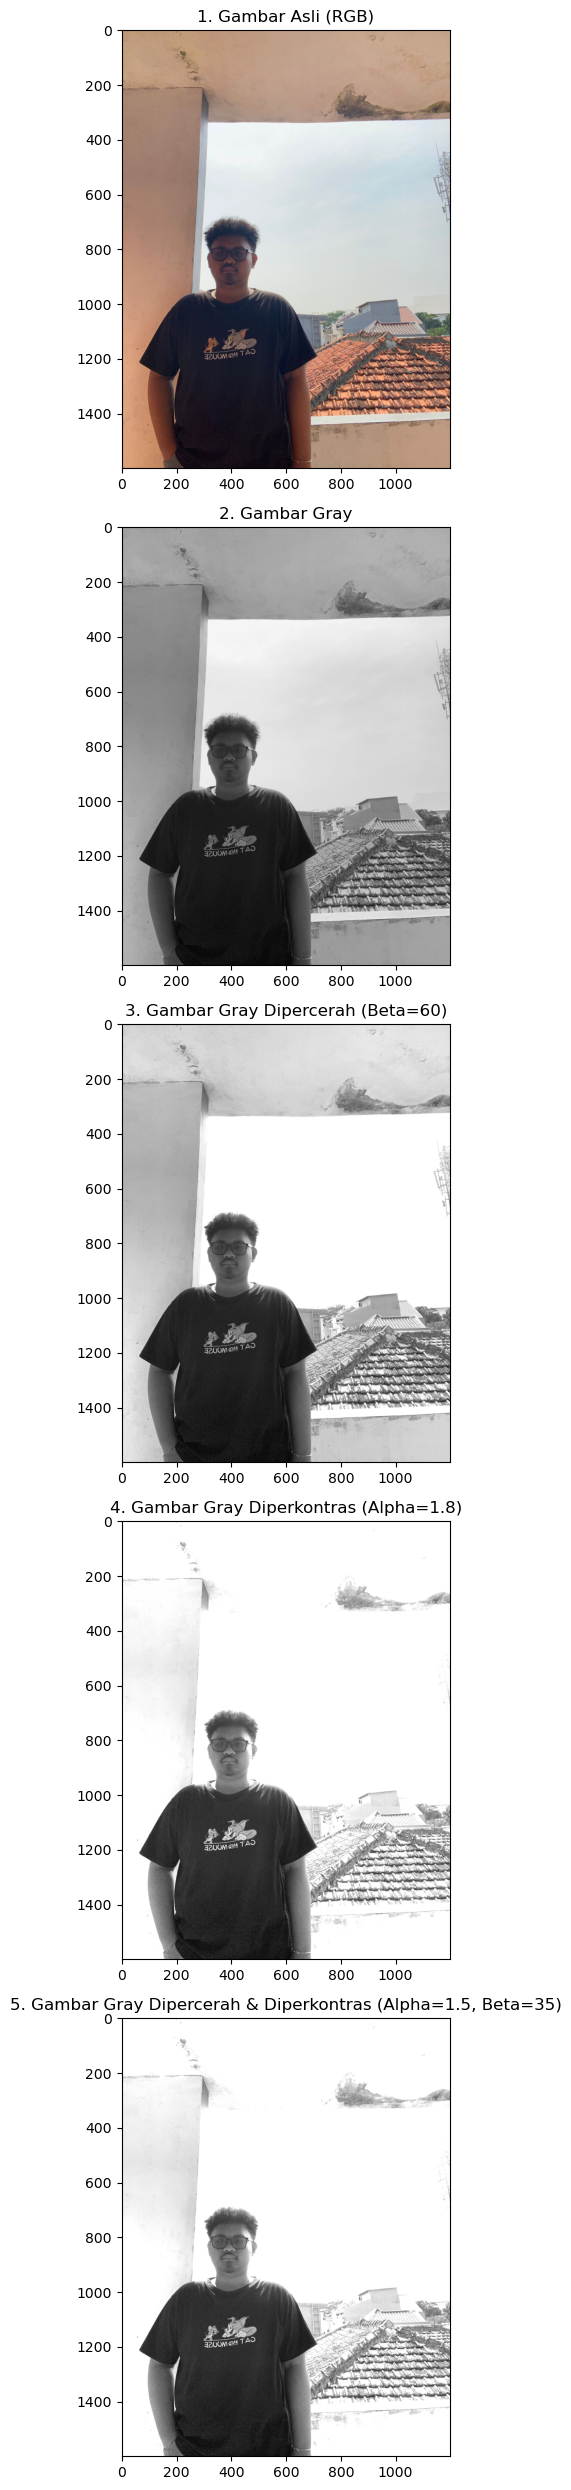

In [12]:

gray_backlight = cv2.cvtColor(img_backlight, cv2.COLOR_RGB2GRAY)



beta_only = 60 # Menaikkan kecerahan 60 poin
brightened = cv2.convertScaleAbs(gray_backlight, alpha=1.0, beta=beta_only)


alpha_only = 1.8 # Menaikkan kontras 80%
contrasted = cv2.convertScaleAbs(gray_backlight, alpha=alpha_only, beta=0)


best_alpha = 1.5 
best_beta = 35   
final_result = cv2.convertScaleAbs(gray_backlight, alpha=best_alpha, beta=best_beta)


plt.figure(figsize=(10, 25)) 
plt.subplot(5, 1, 1)
plt.imshow(img_backlight); plt.title('1. Gambar Asli (RGB)')

plt.subplot(5, 1, 2)
plt.imshow(gray_backlight, cmap='gray'); plt.title('2. Gambar Gray')

plt.subplot(5, 1, 3)
plt.imshow(brightened, cmap='gray'); plt.title(f'3. Gambar Gray Dipercerah (Beta={beta_only})')

plt.subplot(5, 1, 4)
plt.imshow(contrasted, cmap='gray'); plt.title(f'4. Gambar Gray Diperkontras (Alpha={alpha_only})')

plt.subplot(5, 1, 5)
plt.imshow(final_result, cmap='gray'); plt.title(f'5. Gambar Gray Dipercerah & Diperkontras (Alpha={best_alpha}, Beta={best_beta})')

plt.tight_layout()
plt.show()